<a href="https://colab.research.google.com/github/vishnoo-prasad-m/learning-repo/blob/main/Copy_of_(working_CNN_BiLSTM)testing_5%2C6_trained_successful_LSTM_architecture_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The code to load the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### libraries

In [ ]:
!pip install pyswarm

  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4463 sha256=ab1e7b267b9173761815c128ae8688afdf6a7378837d281f372ab83fc20196a3
  Stored in directory: /root/.cache/pip/wheels/71/67/40/62fa158f497f942277cbab8199b05cb61c571ab324e67ad0d6
Successfully built pyswarm


In [ ]:
!pip install tensorflow

In [ ]:
!pip install --upgrade google-colab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.7 MB/s eta 0:00:00


### charge + discharge (present)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from pyswarm import pso
from scipy.io import loadmat
import datetime
import matplotlib.pyplot as plt

def load_data(battery):
    mat = loadmat('/content/drive/MyDrive/Nasa_battery_dataset/' + battery + '.mat')
    print('Total data in dataset: ', len(mat[battery][0, 0]['cycle'][0]))
    counter = 0
    dataset = []
    capacity_data = []
    previous_capacity = None  # Initialize previous capacity as None

    for i in range(len(mat[battery][0, 0]['cycle'][0])):
        row = mat[battery][0, 0]['cycle'][0, i]

        if row['type'][0] == 'discharge':
            ambient_temperature = row['ambient_temperature'][0][0]
            date_time = datetime.datetime(int(row['time'][0][0]),
                                       int(row['time'][0][1]),
                                       int(row['time'][0][2]),
                                       int(row['time'][0][3]),
                                       int(row['time'][0][4])) + datetime.timedelta(seconds=int(row['time'][0][5]))
            data = row['data']
            for j in range(len(data[0][0]['Voltage_measured'][0])):
                voltage_measured = data[0][0]['Voltage_measured'][0][j]
                current_measured = data[0][0]['Current_measured'][0][j]
                temperature_measured = data[0][0]['Temperature_measured'][0][j]
                time = data[0][0]['Time'][0][j]
                capacity = data[0][0]['Capacity'][0][0]
                dataset.append([counter + 1, ambient_temperature, date_time, capacity,
                                voltage_measured, current_measured,
                                temperature_measured, time])
            capacity_data.append([counter + 1, ambient_temperature, date_time, capacity])
            previous_capacity = capacity  # Update previous capacity

        elif row['type'][0] == 'charge':
            ambient_temperature = row['ambient_temperature'][0][0]
            date_time = datetime.datetime(int(row['time'][0][0]),
                                       int(row['time'][0][1]),
                                       int(row['time'][0][2]),
                                       int(row['time'][0][3]),
                                       int(row['time'][0][4])) + datetime.timedelta(seconds=int(row['time'][0][5]))
            data = row['data']
            for j in range(len(data[0][0]['Voltage_measured'][0])):
                voltage_measured = data[0][0]['Voltage_measured'][0][j]
                current_measured = data[0][0]['Current_measured'][0][j]
                temperature_measured = data[0][0]['Temperature_measured'][0][j]
                time = data[0][0]['Time'][0][j]
            if previous_capacity is not None:
                dataset.append([counter + 1, ambient_temperature, date_time, previous_capacity,
                                voltage_measured, current_measured,
                                temperature_measured, time])
            else:
                # Skip charge data point if no previous capacity available
                continue
        counter = counter + 1
    print(dataset[0])
    return [pd.DataFrame(data=dataset, columns=['cycle', 'ambient_temperature', 'datetime',
                                                'capacity', 'voltage_measured',
                                                'current_measured', 'temperature_measured',
                                                 'time']),
            pd.DataFrame(data=capacity_data,
                         columns=['cycle', 'ambient_temperature', 'datetime',
                                  'capacity'])]

##normalization of data

the BILSTM like Neural Net models requires only the V,I,T no need for cycle and time

In [ ]:
def normalize_data(dataset):

    # Normalize the voltage measured data to a range of 0 to 1
    dataset['voltage_measured'] = (dataset['voltage_measured'] - dataset['voltage_measured'].min()) / (dataset['voltage_measured'].max() - dataset['voltage_measured'].min())

    # Normalize the current measured data to a range of 0 to 1
    dataset['current_measured'] = (dataset['current_measured'] - dataset['current_measured'].min()) / (dataset['current_measured'].max() - dataset['current_measured'].min())

    # Normalize the temperature measured data to a range of 0 to 1
    dataset['temperature_measured'] = (dataset['temperature_measured'] - dataset['temperature_measured'].min()) / (dataset['temperature_measured'].max() - dataset['temperature_measured'].min())

    # Normalize the capacity to a range of 0 to 1
    dataset['capacity'] = (dataset['capacity'] - dataset['capacity'].min()) / (dataset['capacity'].max() - dataset['capacity'].min())

     # Normalize the cycle to a range of 0 to 1
    dataset['cycle'] = (dataset['cycle'] - dataset['cycle'].min()) / (dataset['cycle'].max() - dataset['cycle'].min())

    return dataset

## CNN_BiLSTM model with cycle, time features inculded in input

### old model code suitable for CHARGE + DISCHARGE (present)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
from pyswarm import pso
from scipy.io import loadmat
import datetime

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # Include cycle and time as features

# Load multiple datasets and combine them for training and testing
datasets_to_load = ['B0005']  # Add more dataset names if needed
combined_dataset = pd.DataFrame()
for dataset_name in datasets_to_load:
    dataset, capacity = load_data(dataset_name)
    dataset = normalize_data(dataset)
    combined_dataset = pd.concat([combined_dataset, dataset], ignore_index=True)

# Split the combined dataset into training and testing sets
X_combined = combined_dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y_combined = combined_dataset['capacity']
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(X_combined, y_combined, test_size=0.1, random_state=42)

# Reshape combined training data
num_samples_train_combined = len(X_train_combined)
reshaped_features_train_combined = np.zeros((num_samples_train_combined, sequence_length, num_features))
for i, (_, row) in enumerate(X_train_combined.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features_train_combined[i, :, :] = np.array([cycle, voltage, current, temperature])

# Reshape combined testing data
num_samples_test_combined = len(X_test_combined)
reshaped_features_test_combined = np.zeros((num_samples_test_combined, sequence_length, num_features))
for i, (_, row) in enumerate(X_test_combined.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features_test_combined[i, :, :] = np.array([cycle, voltage, current, temperature])

# Define input shape and number of classes
input_shape = (sequence_length, num_features)
num_classes = 1

# Model code
def ECM_LSTM(input_shape, num_classes):
    input_layer = Input(shape=input_shape, name='Input')

    # Convolutional Layers
    conv1 = Conv1D(filters=18, kernel_size=7, strides=2, padding='same', activation='relu')(input_layer)
    pool1 = MaxPooling1D(pool_size=3, strides=2, padding='valid')(conv1)
    conv2 = Conv1D(filters=36, kernel_size=1, strides=2, padding='same', activation='relu')(pool1)

    # Dilated Convolutional Layers
    dilated_conv1 = Conv1D(filters=36, kernel_size=3, strides=2, padding='same', dilation_rate=1, activation='relu')(pool1)
    dilated_conv2 = Conv1D(filters=72, kernel_size=3, strides=1, padding='same', dilation_rate=2, activation='relu')(dilated_conv1)
    dilated_conv3 = Conv1D(filters=36, kernel_size=1, strides=1, padding='same', dilation_rate=6, activation='relu')(dilated_conv2)

    # SE Block
    se_input = Multiply()([conv2, dilated_conv3])

    # LSTM Layer
    lstm = LSTM(units=72, return_sequences=True)(se_input)

    # Flattening and Dense Layers
    flatten = Flatten()(lstm)
    dense1 = Dense(units=3, activation='relu')(flatten)
    dense2 = Dense(units=750, activation='relu')(dense1)
    dense3 = Dense(units=50, activation='relu')(dense2)

    # Output Layer
    output_layer = Dense(units=num_classes, activation='linear', name='Output')(dense3)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='HFCM_LSTM_Model')
    return model


# Create the model
model = ECM_LSTM(input_shape, num_classes)

# Compile the model
model.compile(loss='mean_squared_error', metrics=['mse', 'mae', tf.keras.metrics.RootMeanSquaredError()])

# Train the model on the combined dataset
model.fit(reshaped_features_train_combined, y_train_combined, epochs=2, batch_size=32, validation_split=0.2)

# Evaluate the model on the combined testing data
loss_combined, mse_combined, mae_combined, rmse_combined = model.evaluate(reshaped_features_test_combined, y_test_combined)
print("Combined Mean Square Error:", mse_combined)
print("Combined Mean Absolute Error:", mae_combined)
print("Combined Root Mean Square Error:", rmse_combined)

Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.004901589207462691, 24.330033885570543, 0.0]
Epoch 1/2
1136/1136 [==============================] - 78s 65ms/step - loss: 0.0084 - mse: 0.0084 - mae: 0.0648 - root_mean_squared_error: 0.0918 - val_loss: 0.0056 - val_mse: 0.0056 - val_mae: 0.0635 - val_root_mean_squared_error: 0.0746
Epoch 2/2
158/158 [==============================] - 3s 17ms/step - loss: 0.0015 - mse: 0.0015 - mae: 0.0319 - root_mean_squared_error: 0.0387
Combined Mean Square Error: 0.001497154589742422
Combined Mean Absolute Error: 0.0318855457007885
Combined Root Mean Square Error: 0.038693081587553024


### ***working*** BiLSTM old model code suitable for CHARGE + DISCHARGE (present)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
from pyswarm import pso
from scipy.io import loadmat
import datetime

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # Include cycle as features

# Load multiple datasets and combine them for training and testing
datasets_to_load = ['B0005','B0006']  # Add more dataset names if needed
combined_dataset = pd.DataFrame()
for dataset_name in datasets_to_load:
    dataset, capacity = load_data(dataset_name)
    dataset = normalize_data(dataset)
    combined_dataset = pd.concat([combined_dataset, dataset], ignore_index=True)

# Split the combined dataset into training and testing sets
X_combined = combined_dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y_combined = combined_dataset['capacity']
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(X_combined, y_combined, test_size=0.1, random_state=42)

# Reshape combined training data
num_samples_train_combined = len(X_train_combined)
reshaped_features_train_combined = np.zeros((num_samples_train_combined, sequence_length, num_features))
for i, (_, row) in enumerate(X_train_combined.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features_train_combined[i, :, :] = np.array([cycle, voltage, current, temperature])

# Reshape combined testing data
num_samples_test_combined = len(X_test_combined)
reshaped_features_test_combined = np.zeros((num_samples_test_combined, sequence_length, num_features))
for i, (_, row) in enumerate(X_test_combined.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features_test_combined[i, :, :] = np.array([cycle, voltage, current, temperature])

# Define input shape and number of classes
input_shape = (sequence_length, num_features)
num_classes = 1

# Model code
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Flatten, Dense, Bidirectional, Multiply

def model_creation(input_shape, num_classes):
    input_layer = Input(shape=input_shape, name='Input')

    # Convolutional Layers
    conv1 = Conv1D(filters=18, kernel_size=7, strides=2, padding='same', activation='relu')(input_layer)
    pool1 = MaxPooling1D(pool_size=3, strides=2, padding='valid')(conv1)
    conv2 = Conv1D(filters=36, kernel_size=1, strides=2, padding='same', activation='relu')(pool1)

    # Dilated Convolutional Layers
    dilated_conv1 = Conv1D(filters=36, kernel_size=3, strides=2, padding='same', dilation_rate=1, activation='relu')(pool1)
    dilated_conv2 = Conv1D(filters=72, kernel_size=3, strides=1, padding='same', dilation_rate=2, activation='relu')(dilated_conv1)
    dilated_conv3 = Conv1D(filters=36, kernel_size=1, strides=1, padding='same', dilation_rate=6, activation='relu')(dilated_conv2)

    # SE Block
    se_input = Multiply()([conv2, dilated_conv3])

    # Bidirectional LSTM Layer
    bi_lstm = Bidirectional(LSTM(units=72, return_sequences=True))(se_input)

    # Flattening and Dense Layers
    flatten = Flatten()(bi_lstm)
    dense1 = Dense(units=3, activation='relu')(flatten)
    dense2 = Dense(units=750, activation='relu')(dense1)
    dense3 = Dense(units=50, activation='relu')(dense2)

    # Output Layer
    output_layer = Dense(units=num_classes, activation='linear', name='Output')(dense3)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='HFCM_BiLSTM_Model')
    return model


# Create the model
model = HFCM_BiLSTM(input_shape, num_classes)

# Compile the model
model.compile(loss='mean_squared_error', metrics=['mse', 'mae', tf.keras.metrics.RootMeanSquaredError()])

# Train the model on the combined dataset
model.fit(reshaped_features_train_combined, y_train_combined, epochs=2, batch_size=32, validation_split=0.2)

# Evaluate the model on the combined testing data
loss_combined, mse_combined, mae_combined, rmse_combined = model.evaluate(reshaped_features_test_combined, y_test_combined)
print("Combined Mean Square Error:", mse_combined)
print("Combined Mean Absolute Error:", mae_combined)
print("Combined Root Mean Square Error:", rmse_combined)



Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.004901589207462691, 24.330033885570543, 0.0]
Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 2.035337591005598, 4.179799607333447, -0.0023663271409738672, 24.277567510331888, 0.0]
Epoch 1/2
2271/2271 [==============================] - 238s 96ms/step - loss: 0.0083 - mse: 0.0083 - mae: 0.0680 - root_mean_squared_error: 0.0913 - val_loss: 0.0038 - val_mse: 0.0038 - val_mae: 0.0511 - val_root_mean_squared_error: 0.0619
Epoch 2/2
316/316 [==============================] - 8s 27ms/step - loss: 0.0035 - mse: 0.0035 - mae: 0.0475 - root_mean_squared_error: 0.0590
Combined Mean Square Error: 0.0034853415563702583
Combined Mean Absolute Error: 0.04752743989229202
Combined Root Mean Square Error: 0.05903678014874458


In [ ]:
predicted_capacity = model.predict(reshaped_features_test_combined)
predicted_capacity = predicted_capacity.flatten()
print(y_test_combined.shape)



316/316 [==============================] - 11s 30ms/step
(10091,)


### actual HFCM LSTM model suitable for CHARGE + DISCHARGE (present)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
from pyswarm import pso
from scipy.io import loadmat
import datetime

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # Include cycle and time as features

# Load multiple datasets and combine them for training and testing
datasets_to_load = ['B0005']  # Add more dataset names if needed
combined_dataset = pd.DataFrame()
for dataset_name in datasets_to_load:
    dataset, capacity = load_data(dataset_name)
    dataset = normalize_data(dataset)
    combined_dataset = pd.concat([combined_dataset, dataset], ignore_index=True)

# Split the combined dataset into training and testing sets
X_combined = combined_dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y_combined = combined_dataset['capacity']
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(X_combined, y_combined, test_size=0.1, random_state=42)

# Reshape combined training data
num_samples_train_combined = len(X_train_combined)
reshaped_features_train_combined = np.zeros((num_samples_train_combined, sequence_length, num_features))
for i, (_, row) in enumerate(X_train_combined.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features_train_combined[i, :, :] = np.array([cycle, voltage, current, temperature])

# Reshape combined testing data
num_samples_test_combined = len(X_test_combined)
reshaped_features_test_combined = np.zeros((num_samples_test_combined, sequence_length, num_features))
for i, (_, row) in enumerate(X_test_combined.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features_test_combined[i, :, :] = np.array([cycle, voltage, current, temperature])

# Define input shape and number of classes
input_shape = (sequence_length, num_features)
num_classes = 1


Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.004901589207462691, 24.330033885570543, 0.0]


In [ ]:

# Define the desired sequence length and number of features
desired_sequence_length = 400
desired_num_features = 4

# Reshape the training data
reshaped_features_train_combined = reshaped_features_train_combined[:, :desired_sequence_length, :desired_num_features]

# Reshape the testing data
reshaped_features_test_combined = reshaped_features_test_combined[:, :desired_sequence_length, :desired_num_features]

# Now, your data is in the desired format of 400 x 4 sequences

# Define the input shape for the model
input_shape = (desired_sequence_length, desired_num_features)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Multiply, LSTM, Flatten, Dense, Add

def custom_convolution_block(input_layer):
    # Standard Convolution
    conv2 = Conv1D(filters=64, kernel_size=1, strides=2, padding='same', activation='relu')(input_layer)

    # Dilated Convolutional Layers
    dilated_conv1 = Conv1D(filters=64, kernel_size=3, strides=2, padding='same', dilation_rate=1, activation='relu')(input_layer)
    dilated_conv2 = Conv1D(filters=128, kernel_size=3, strides=1, padding='same', dilation_rate=2, activation='relu')(dilated_conv1)
    dilated_conv3 = Conv1D(filters=64, kernel_size=1, strides=1, padding='same', dilation_rate=6, activation='relu')(dilated_conv2)

    return conv2, dilated_conv1, dilated_conv2, dilated_conv3

def custom_convolution_block2(input_layer):
    # Standard Convolution
    conv2 = Conv1D(filters=64, kernel_size=1, strides=2, padding='same', activation='relu')(input_layer)

    # Dilated Convolutional Layers
    dilated_conv1 = Conv1D(filters=64, kernel_size=3, strides=2, padding='same', dilation_rate=1, activation='relu')(input_layer)
    dilated_conv2 = Conv1D(filters=128, kernel_size=3, strides=1, padding='same', dilation_rate=2, activation='relu')(dilated_conv1)
    dilated_conv3 = Conv1D(filters=64, kernel_size=1, strides=1, padding='same', dilation_rate=6, activation='relu')(dilated_conv2)

    return conv2, dilated_conv1, dilated_conv2, dilated_conv3

import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Reshape, Multiply

def se_block(input_layer, ratio=16):
    # Global Average Pooling
    x = GlobalAveragePooling1D()(input_layer)

    # Squeeze (Reduce) Phase
    x = Dense(units=int(input_layer.shape[-1]) // ratio, activation='relu')(x)

    # Excitation (Expand) Phase
    x = Dense(units=input_layer.shape[-1], activation='sigmoid')(x)

    # Reshape for multiplication
    x = Reshape((1, -1))(x)

    # Multiply the input tensor by the attention weights
    se_output = Multiply()([input_layer, x])

    return se_output


import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Multiply, LSTM, Flatten, Dense, Add, Concatenate, Attention



# Model code with 1D CNN parallel to each custom convolution block with SE block and adaptive fusion using attention
def HFCM_LSTM(input_shape, num_classes):
    input_layer = Input(shape=input_shape, name='Input')

    # Convolutional Layers
    conv1 = Conv1D(filters=32, kernel_size=7, strides=2, padding='same', activation='relu')(input_layer)
    pool1 = MaxPooling1D(pool_size=3, strides=2, padding='valid')(conv1)

    # First Custom Convolution Block with SE block
    conv1_1, dilated_conv1_1, dilated_conv2_1, dilated_conv3_1 = custom_convolution_block(pool1)
    se_output1 = se_block(dilated_conv3_1)

    # Parallel 1D CNN layer
    cnn1 = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')(pool1)

    # Adaptive Fusion using Attention Mechanism
    attention_weights1 = Attention()([cnn1, se_output1])
    fused_output1 = Multiply()([cnn1, attention_weights1])

    # Second Custom Convolution Block with SE block
    conv1_2, dilated_conv1_2, dilated_conv2_2, dilated_conv3_2 = custom_convolution_block2(fused_output1)
    se_output2 = se_block(dilated_conv3_2)

    # Parallel 1D CNN layer
    cnn2 = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu')(fused_output1)

    # Adaptive Fusion using Attention Mechanism
    attention_weights2 = Attention()([cnn2, se_output2])
    fused_output2 = Multiply()([cnn2, attention_weights2])

    # First LSTM Layer
    lstm1 = LSTM(units=72, return_sequences=True)(fused_output2)

    # Second LSTM Layer
    lstm2 = LSTM(units=72, return_sequences=True)(lstm1)

    # Flattening and Dense Layers
    flatten = Flatten()(lstm2)
    dense1 = Dense(units=3, activation='relu')(flatten)
    dense2 = Dense(units=750, activation='relu')(dense1)
    dense3 = Dense(units=50, activation='relu')(dense2)

    # Output Layer
    output_layer = Dense(units=num_classes, activation='linear', name='Output')(dense3)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='HFCM_LSTM_Model')
    return model


In [ ]:
# Create the model
model = HFCM_LSTM(input_shape, num_classes)

# Compile the model
model.compile(loss='mean_squared_error', metrics=['mse', 'mae', tf.keras.metrics.RootMeanSquaredError()])

# Train the model on the combined dataset
model.fit(reshaped_features_train_combined, y_train_combined, epochs=2, batch_size=32, validation_split=0.2)

# Evaluate the model on the combined testing data
loss_combined, mse_combined, mae_combined, rmse_combined = model.evaluate(reshaped_features_test_combined, y_test_combined)
print("Combined Mean Square Error:", mse_combined)
print("Combined Mean Absolute Error:", mae_combined)
print("Combined Root Mean Square Error:", rmse_combined)

NameError: ignored

### to save the model   (each time update this if you train a model)

In [ ]:
# Save the trained model's weights
path_to_saved_weights = '/content/drive/MyDrive/Nasa_battery_dataset/OHIO.h5'
model.save_weights(path_to_saved_weights)

# RESULTS OF BiLSTM model code suitable for CHARGE + DISCHARGE (present)

## testing dataset using B0007 for **BiLSTM model code suitable for CHARGE + DISCHARGE (present)**

Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.0018658918833680202, 23.93704394613529, 0.0]
1577/1577 [==============================] - 39s 24ms/step
Cycle 0.0 - Predicted Capacity: 0.9321194291114807
Cycle 0.0016286644951140066 - Predicted Capacity: 0.9276986122131348
Cycle 0.003257328990228013 - Predicted Capacity: 0.9312224388122559
Cycle 0.004885993485342019 - Predicted Capacity: 0.9264180660247803
Cycle 0.006514657980456026 - Predicted Capacity: 0.9295676350593567
Cycle 0.008143322475570033 - Predicted Capacity: 0.9246689081192017
Cycle 0.009771986970684038 - Predicted Capacity: 0.9276039004325867
Cycle 0.011400651465798045 - Predicted Capacity: 0.9228264093399048
Cycle 0.013029315960912053 - Predicted Capacity: 0.9258050918579102
Cycle 0.014657980456026058 - Predicted Capacity: 0.9213470220565796
Cycle 0.016286644951140065 - Predicted Capacity: 0.92452472448349
Cycle 0.017915309446254073 - Predicted Capacity

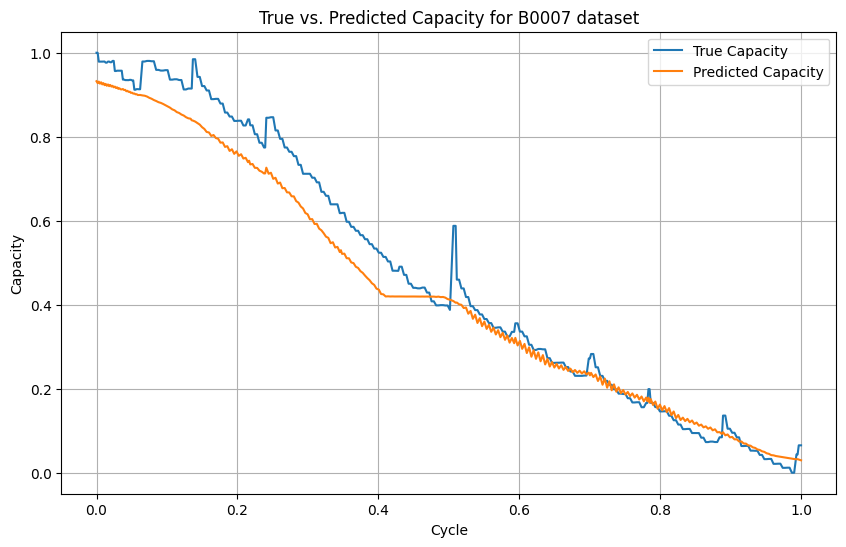

Mean Absolute Error (MAE): 0.04658029412889802
Mean Squared Error (MSE): 0.0036522851716095962
Root Mean Squared Error (RMSE): 0.060434139123591364


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0007')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

input_shape = (sequence_length, num_features)

# Load the trained model weights
model = HFCM_BiLSTM(input_shape, num_classes)
model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Flatten the predicted_capacity array to have a single value per point
predicted_capacity = predicted_capacity.flatten()
# for i, value in enumerate(predicted_capacity):
#     print(f"Cycle {X['cycle'][i]} - Predicted Capacity: {value}")

cycle_dict = {}
average_dict = {}

for i,cycle in enumerate(X['cycle']):
  if cycle not in cycle_dict:
    cycle_dict[cycle]=[predicted_capacity[i]]
  else:
    cycle_dict[cycle].append(predicted_capacity[i])
for cycle,capacities in cycle_dict.items():
  average_dict[cycle]=np.mean(capacities)

cycle_values=[]
average_values=[]

for i, cycle in enumerate(cycle_dict):
    if i == 0:
        cycle_values.append(cycle)
        average_values.append(average_dict[cycle])
    else:
        # Check if the difference is greater than or equal to 0.015
        diff = abs(average_dict[cycle] - average_dict[cycle_values[-1]])
        if diff >= 0.015:
          cycle_values.append(cycle)
          average_values.append(average_dict[cycle])

for i, value in enumerate(average_values):
    print(f"Cycle {cycle_values[i]} - Predicted Capacity: {value}")

plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(cycle_values, average_values, label='Predicted Capacity')
print(predicted_capacity.shape)
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0007 dataset')
plt.legend()
plt.grid()
plt.show()

# extended_average_values = []

# # Initialize an index variable
# index = 0

# # Iterate over the cycles in X['cycle']
# for cycle in X['cycle']:
#     # Check if the cycle exists in cycle_values
#     if cycle in cycle_values:
#         # If it exists, add the corresponding average capacity value
#         extended_average_values.append(average_dict[cycle])
#     else:
#         # If it doesn't exist, use the last available average capacity value
#         # Ensure the index doesn't exceed the length of average_values
#         index = min(index, len(average_values) - 1)
#         extended_average_values.append(average_values[index])

#     # Increment the index
#     index += 1

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from scipy.interpolate import interp1d

# Create an interpolation function using cycle_values and average_values
interp_func = interp1d(cycle_values, average_values, kind='linear', fill_value='extrapolate')

# Use the interpolation function to estimate values for all cycles in X['cycle']
extended_average_values = interp_func(X['cycle'])

# Calculate error metrics
mae = mean_absolute_error(y, extended_average_values)
mse = mean_squared_error(y, extended_average_values)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

testing dataset using B0036 for BiLSTM model code suitable for CHARGE + DISCHARGE (present)

Total data in dataset:  486
[1, 24, datetime.datetime(2009, 6, 19, 17, 18, 16), 1.001982588175331, 3.848136609578083, -0.0021557335495844556, 23.91297719702689, 0.0]
1477/1477 [==============================] - 37s 24ms/step
Cycle 0.0 - Predicted Capacity: 0.8613065481185913
Cycle 0.004132231404958678 - Predicted Capacity: 0.9187440872192383
Cycle 0.008264462809917356 - Predicted Capacity: 0.8753860592842102
Cycle 0.010330578512396695 - Predicted Capacity: 0.9129155874252319
Cycle 0.012396694214876033 - Predicted Capacity: 0.8726631999015808
Cycle 0.014462809917355372 - Predicted Capacity: 0.9092943668365479
Cycle 0.01652892561983471 - Predicted Capacity: 0.8691896200180054
Cycle 0.01859504132231405 - Predicted Capacity: 0.9061251878738403
Cycle 0.02066115702479339 - Predicted Capacity: 0.8646543622016907
Cycle 0.022727272727272728 - Predicted Capacity: 0.9024770259857178
Cycle 0.024793388429752067 - Predicted Capacity: 0.8599788546562195
Cycle 0.028925619834710745 - Predicted Capacity

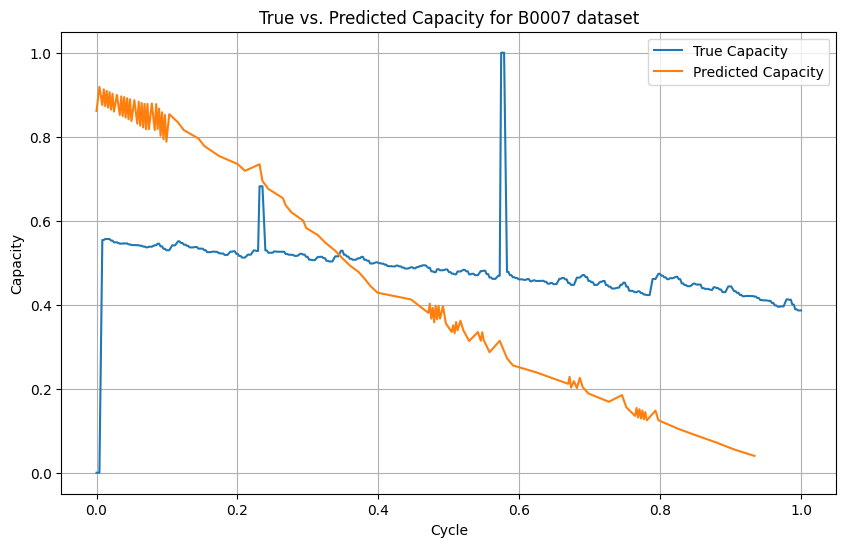

Mean Absolute Error (MAE): 0.22432734782574104
Mean Squared Error (MSE): 0.06499118546852287
Root Mean Squared Error (RMSE): 0.2549336883750809


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0036')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

input_shape = (sequence_length, num_features)

# Load the trained model weights
model = HFCM_BiLSTM(input_shape, num_classes)
model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Flatten the predicted_capacity array to have a single value per point
predicted_capacity = predicted_capacity.flatten()
# for i, value in enumerate(predicted_capacity):
#     print(f"Cycle {X['cycle'][i]} - Predicted Capacity: {value}")

cycle_dict = {}
average_dict = {}

for i,cycle in enumerate(X['cycle']):
  if cycle not in cycle_dict:
    cycle_dict[cycle]=[predicted_capacity[i]]
  else:
    cycle_dict[cycle].append(predicted_capacity[i])
for cycle,capacities in cycle_dict.items():
  average_dict[cycle]=np.mean(capacities)

cycle_values=[]
average_values=[]

for i, cycle in enumerate(cycle_dict):
    if i == 0:
        cycle_values.append(cycle)
        average_values.append(average_dict[cycle])
    else:
        # Check if the difference is greater than or equal to 0.015
        diff = abs(average_dict[cycle] - average_dict[cycle_values[-1]])
        if diff >= 0.015:
            cycle_values.append(cycle)
            average_values.append(average_dict[cycle])

for i, value in enumerate(average_values):
    print(f"Cycle {cycle_values[i]} - Predicted Capacity: {value}")

plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(cycle_values, average_values, label='Predicted Capacity')
print(predicted_capacity.shape)
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0007 dataset')
plt.legend()
plt.grid()
plt.show()

# extended_average_values = []

# # Initialize an index variable
# index = 0

# # Iterate over the cycles in X['cycle']
# for cycle in X['cycle']:
#     # Check if the cycle exists in cycle_values
#     if cycle in cycle_values:
#         # If it exists, add the corresponding average capacity value
#         extended_average_values.append(average_dict[cycle])
#     else:
#         # If it doesn't exist, use the last available average capacity value
#         # Ensure the index doesn't exceed the length of average_values
#         index = min(index, len(average_values) - 1)
#         extended_average_values.append(average_values[index])

#     # Increment the index
#     index += 1

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from scipy.interpolate import interp1d

# Create an interpolation function using cycle_values and average_values
interp_func = interp1d(cycle_values, average_values, kind='linear', fill_value='extrapolate')

# Use the interpolation function to estimate values for all cycles in X['cycle']
extended_average_values = interp_func(X['cycle'])

# Calculate error metrics
mae = mean_absolute_error(y, extended_average_values)
mse = mean_squared_error(y, extended_average_values)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

testing b0032

Total data in dataset:  97
[2, 43, datetime.datetime(2009, 4, 7, 16, 31, 1), 1.7048641073512139, 4.087016142066692, -0.0030060663936215554, 43.26523418326313, 0.0]
200/200 [==============================] - 8s 31ms/step
Cycle 0.0 - Predicted Capacity: 0.9059722423553467
Cycle 0.010638297872340425 - Predicted Capacity: 0.924010157585144
Cycle 0.02127659574468085 - Predicted Capacity: 0.9061359763145447
Cycle 0.031914893617021274 - Predicted Capacity: 0.9147622585296631
Cycle 0.0425531914893617 - Predicted Capacity: 0.8963425159454346
Cycle 0.05319148936170213 - Predicted Capacity: 0.9039477109909058
Cycle 0.06382978723404255 - Predicted Capacity: 0.8840265274047852
Cycle 0.07446808510638298 - Predicted Capacity: 0.8927474021911621
Cycle 0.0851063829787234 - Predicted Capacity: 0.8681820034980774
Cycle 0.10638297872340426 - Predicted Capacity: 0.8710179328918457
Cycle 0.1276595744680851 - Predicted Capacity: 0.827594518661499
Cycle 0.13829787234042554 - Predicted Capacity: 0.840530753135

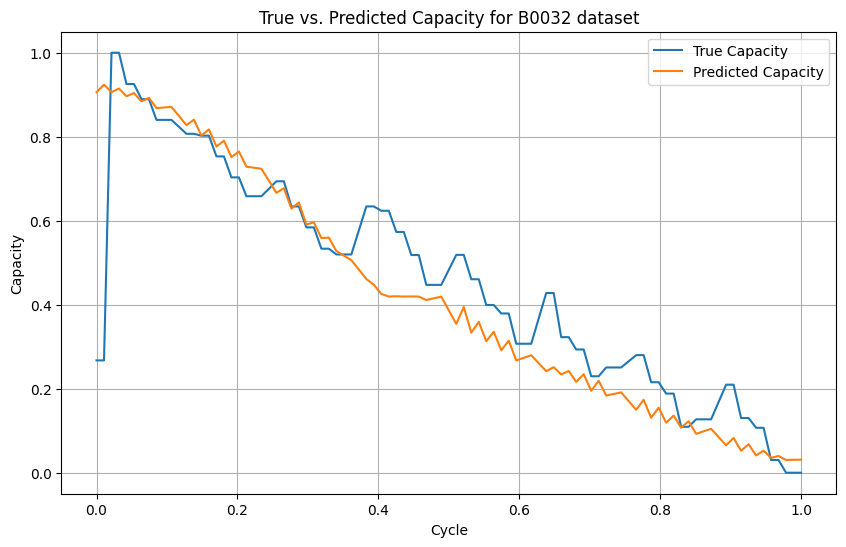

Mean Absolute Error (MAE): 0.08247333375728678
Mean Squared Error (MSE): 0.018258903803446705
Root Mean Squared Error (RMSE): 0.13512551129763287


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0032')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

input_shape = (sequence_length, num_features)

# Load the trained model weights
model = HFCM_BiLSTM(input_shape, num_classes)
model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Flatten the predicted_capacity array to have a single value per point
predicted_capacity = predicted_capacity.flatten()
# for i, value in enumerate(predicted_capacity):
#     print(f"Cycle {X['cycle'][i]} - Predicted Capacity: {value}")

cycle_dict = {}
average_dict = {}

for i,cycle in enumerate(X['cycle']):
  if cycle not in cycle_dict:
    cycle_dict[cycle]=[predicted_capacity[i]]
  else:
    cycle_dict[cycle].append(predicted_capacity[i])
for cycle,capacities in cycle_dict.items():
  average_dict[cycle]=np.mean(capacities)

cycle_values=[]
average_values=[]

for i, cycle in enumerate(cycle_dict):
    if i == 0:
        cycle_values.append(cycle)
        average_values.append(average_dict[cycle])
    else:
        # Check if the difference is greater than or equal to 0.015
        # diff = abs(average_dict[cycle] - average_dict[cycle_values[-1]])
        # if diff >= 0.015:
            cycle_values.append(cycle)
            average_values.append(average_dict[cycle])

for i, value in enumerate(average_values):
    print(f"Cycle {cycle_values[i]} - Predicted Capacity: {value}")

plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(cycle_values, average_values, label='Predicted Capacity')
print(predicted_capacity.shape)
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0032 dataset')
plt.legend()
plt.grid()
plt.show()

# extended_average_values = []

# # Initialize an index variable
# index = 0

# # Iterate over the cycles in X['cycle']
# for cycle in X['cycle']:
#     # Check if the cycle exists in cycle_values
#     if cycle in cycle_values:
#         # If it exists, add the corresponding average capacity value
#         extended_average_values.append(average_dict[cycle])
#     else:
#         # If it doesn't exist, use the last available average capacity value
#         # Ensure the index doesn't exceed the length of average_values
#         index = min(index, len(average_values) - 1)
#         extended_average_values.append(average_values[index])

#     # Increment the index
#     index += 1

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from scipy.interpolate import interp1d

# Create an interpolation function using cycle_values and average_values
interp_func = interp1d(cycle_values, average_values, kind='linear', fill_value='extrapolate')

# Use the interpolation function to estimate values for all cycles in X['cycle']
extended_average_values = interp_func(X['cycle'])

# Calculate error metrics
mae = mean_absolute_error(y, extended_average_values)
mse = mean_squared_error(y, extended_average_values)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Total data in dataset:  97
[2, 43, datetime.datetime(2009, 4, 7, 16, 31, 1), 1.6666751942525773, 4.116561748956975, -5.512929124633905e-05, 42.830036312976034, 0.0]
200/200 [==============================] - 11s 44ms/step
Cycle 0.0 - Predicted Capacity: 0.9209694266319275
Cycle 0.05319148936170213 - Predicted Capacity: 0.9057023525238037
Cycle 0.0851063829787234 - Predicted Capacity: 0.8832930326461792
Cycle 0.1276595744680851 - Predicted Capacity: 0.846305787563324
Cycle 0.14893617021276595 - Predicted Capacity: 0.8223319053649902
Cycle 0.1702127659574468 - Predicted Capacity: 0.7952250838279724
Cycle 0.19148936170212766 - Predicted Capacity: 0.7677651047706604
Cycle 0.2127659574468085 - Predicted Capacity: 0.744221568107605
Cycle 0.23404255319148937 - Predicted Capacity: 0.7250269651412964
Cycle 0.2553191489361702 - Predicted Capacity: 0.688389778137207
Cycle 0.2765957446808511 - Predicted Capacity: 0.6495500206947327
Cycle 0.2978723404255319 - Predicted Capacity: 0.6074537634849548


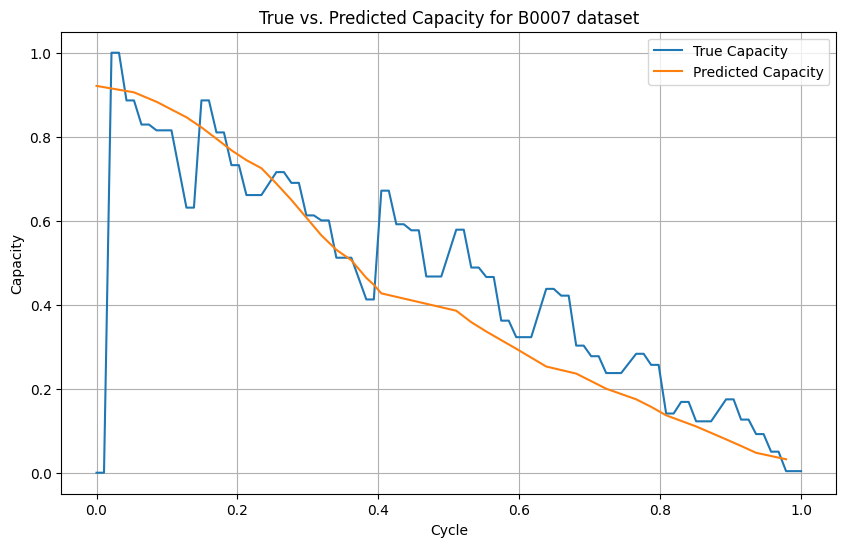

Mean Absolute Error (MAE): 0.10102876839054024
Mean Squared Error (MSE): 0.03247147655973824
Root Mean Squared Error (RMSE): 0.18019843661846305


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0031')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

input_shape = (sequence_length, num_features)

# Load the trained model weights
model = HFCM_BiLSTM(input_shape, num_classes)
model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Flatten the predicted_capacity array to have a single value per point
predicted_capacity = predicted_capacity.flatten()
# for i, value in enumerate(predicted_capacity):
#     print(f"Cycle {X['cycle'][i]} - Predicted Capacity: {value}")

cycle_dict = {}
average_dict = {}

for i,cycle in enumerate(X['cycle']):
  if cycle not in cycle_dict:
    cycle_dict[cycle]=[predicted_capacity[i]]
  else:
    cycle_dict[cycle].append(predicted_capacity[i])
for cycle,capacities in cycle_dict.items():
  average_dict[cycle]=np.mean(capacities)

cycle_values=[]
average_values=[]

for i, cycle in enumerate(cycle_dict):
    if i == 0:
        cycle_values.append(cycle)
        average_values.append(average_dict[cycle])
    else:
        # Check if the difference is greater than or equal to 0.015
        diff = abs(average_dict[cycle] - average_dict[cycle_values[-1]])
        if diff >= 0.015:
            cycle_values.append(cycle)
            average_values.append(average_dict[cycle])

for i, value in enumerate(average_values):
    print(f"Cycle {cycle_values[i]} - Predicted Capacity: {value}")

plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(cycle_values, average_values, label='Predicted Capacity')
print(predicted_capacity.shape)
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0007 dataset')
plt.legend()
plt.grid()
plt.show()

# extended_average_values = []

# # Initialize an index variable
# index = 0

# # Iterate over the cycles in X['cycle']
# for cycle in X['cycle']:
#     # Check if the cycle exists in cycle_values
#     if cycle in cycle_values:
#         # If it exists, add the corresponding average capacity value
#         extended_average_values.append(average_dict[cycle])
#     else:
#         # If it doesn't exist, use the last available average capacity value
#         # Ensure the index doesn't exceed the length of average_values
#         index = min(index, len(average_values) - 1)
#         extended_average_values.append(average_values[index])

#     # Increment the index
#     index += 1

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from scipy.interpolate import interp1d

# Create an interpolation function using cycle_values and average_values
interp_func = interp1d(cycle_values, average_values, kind='linear', fill_value='extrapolate')

# Use the interpolation function to estimate values for all cycles in X['cycle']
extended_average_values = interp_func(X['cycle'])

# Calculate error metrics
mae = mean_absolute_error(y, extended_average_values)
mse = mean_squared_error(y, extended_average_values)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Total data in dataset:  319
[2, 24, datetime.datetime(2008, 7, 7, 15, 15, 28), 1.8550045207910817, 4.188108651124536, 0.00013066734156636677, 23.8195202516044, 0.0]
1094/1094 [==============================] - 25s 22ms/step
Cycle 0.0 - Predicted Capacity: 0.9317126870155334
Cycle 0.006329113924050633 - Predicted Capacity: 0.9322555065155029
Cycle 0.012658227848101266 - Predicted Capacity: 0.9273704290390015
Cycle 0.0189873417721519 - Predicted Capacity: 0.9244129657745361
Cycle 0.02531645569620253 - Predicted Capacity: 0.9188113808631897
Cycle 0.03164556962025317 - Predicted Capacity: 0.9162875413894653
Cycle 0.0379746835443038 - Predicted Capacity: 0.9099305272102356
Cycle 0.04430379746835443 - Predicted Capacity: 0.9155018329620361
Cycle 0.04746835443037975 - Predicted Capacity: 0.910670280456543
Cycle 0.05063291139240506 - Predicted Capacity: 0.9137992858886719
Cycle 0.05379746835443038 - Predicted Capacity: 0.9076134562492371
Cycle 0.056962025316455694 - Predicted Capacity: 0.90846

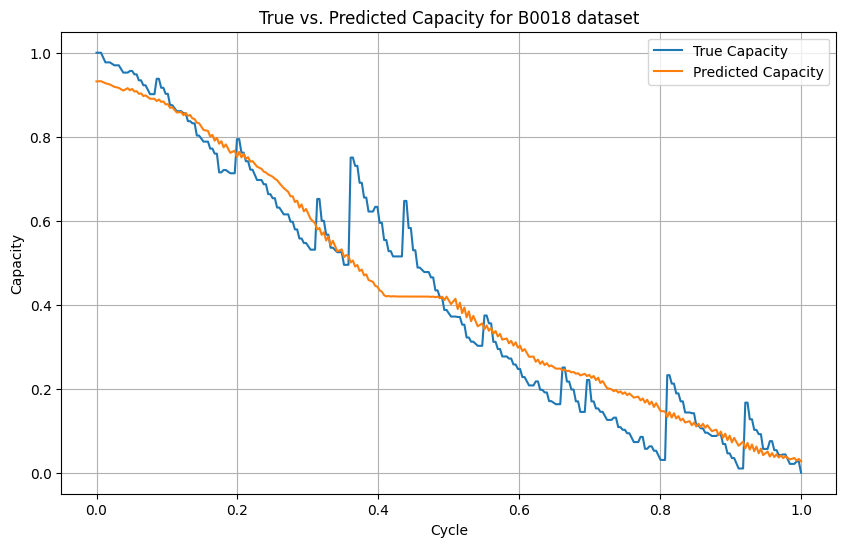

Mean Absolute Error (MAE): 0.0565897005363831
Mean Squared Error (MSE): 0.005752025674729232
Root Mean Squared Error (RMSE): 0.07584211016796165


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0018')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

input_shape = (sequence_length, num_features)

# Load the trained model weights
model = HFCM_BiLSTM(input_shape, num_classes)
model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Flatten the predicted_capacity array to have a single value per point
predicted_capacity = predicted_capacity.flatten()
# for i, value in enumerate(predicted_capacity):
#     print(f"Cycle {X['cycle'][i]} - Predicted Capacity: {value}")

cycle_dict = {}
average_dict = {}

for i,cycle in enumerate(X['cycle']):
  if cycle not in cycle_dict:
    cycle_dict[cycle]=[predicted_capacity[i]]
  else:
    cycle_dict[cycle].append(predicted_capacity[i])
for cycle,capacities in cycle_dict.items():
  average_dict[cycle]=np.mean(capacities)

cycle_values=[]
average_values=[]

for i, cycle in enumerate(cycle_dict):
    if i == 0:
        cycle_values.append(cycle)
        average_values.append(average_dict[cycle])
    else:
        # Check if the difference is greater than or equal to 0.015
            cycle_values.append(cycle)
            average_values.append(average_dict[cycle])

for i, value in enumerate(average_values):
    print(f"Cycle {cycle_values[i]} - Predicted Capacity: {value}")

plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(cycle_values, average_values, label='Predicted Capacity')
print(predicted_capacity.shape)
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0018 dataset')
plt.legend()
plt.grid()
plt.show()

# extended_average_values = []

# # Initialize an index variable
# index = 0

# # Iterate over the cycles in X['cycle']
# for cycle in X['cycle']:
#     # Check if the cycle exists in cycle_values
#     if cycle in cycle_values:
#         # If it exists, add the corresponding average capacity value
#         extended_average_values.append(average_dict[cycle])
#     else:
#         # If it doesn't exist, use the last available average capacity value
#         # Ensure the index doesn't exceed the length of average_values
#         index = min(index, len(average_values) - 1)
#         extended_average_values.append(average_values[index])

#     # Increment the index
#     index += 1

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from scipy.interpolate import interp1d

# Create an interpolation function using cycle_values and average_values
interp_func = interp1d(cycle_values, average_values, kind='linear', fill_value='extrapolate')

# Use the interpolation function to estimate values for all cycles in X['cycle']
extended_average_values = interp_func(X['cycle'])

# Calculate error metrics
mae = mean_absolute_error(y, extended_average_values)
mse = mean_squared_error(y, extended_average_values)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

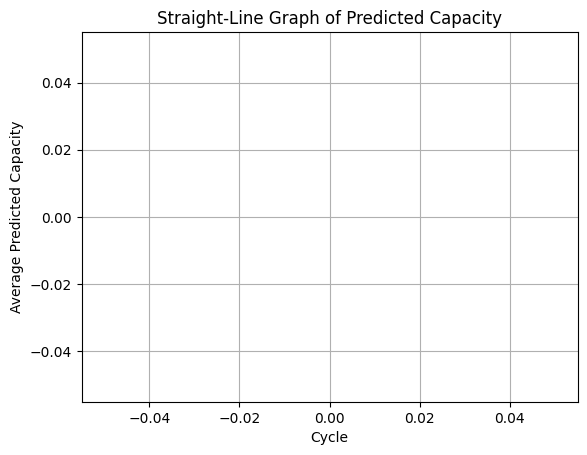

In [ ]:
cycles = X['cycle']  # Replace with your actual data
predicted_capacities = predicted_capacity  # Replace with your actual data

# Initialize dictionaries to store cycle-average pairs
cycle_dict = {}
average_dict = {}

# Calculate the average predicted capacity for each cycle
for i, cycle in enumerate(cycles):
    if cycle not in cycle_dict:
        cycle_dict[cycle] = [predicted_capacities[i]]
    else:
        cycle_dict[cycle].append(predicted_capacities[i])

for cycle, capacities in cycle_dict.items():
    average_dict[cycle] = np.mean(capacities)

# Extract cycles and their corresponding average predicted capacities
cycle_values = []
average_values = []

for i, cycle in enumerate(cycle_values):
    if i == 0:
        cycle_values.append(cycle)
        average_values.append(average_dict[cycle])
    else:
        # Check if the difference is greater than or equal to 0.015
        diff = abs(average_dict[cycle] - average_dict[cycle_values[-1]])
        if diff >= 0.015:
            cycle_values.append(cycle)
            average_values.append(average_dict[cycle])
plt.plot(cycle_values, average_values, marker='o')
plt.xlabel('Cycle')
plt.ylabel('Average Predicted Capacity')
plt.title('Straight-Line Graph of Predicted Capacity')
plt.grid(True)
plt.show()

for i, value in enumerate(average_values):
    print(f"Cycle {cycle_values[i]} - Predicted Capacity: {value}")

### averaged prediction and true capacity also scaled down based on without repetition of capacity

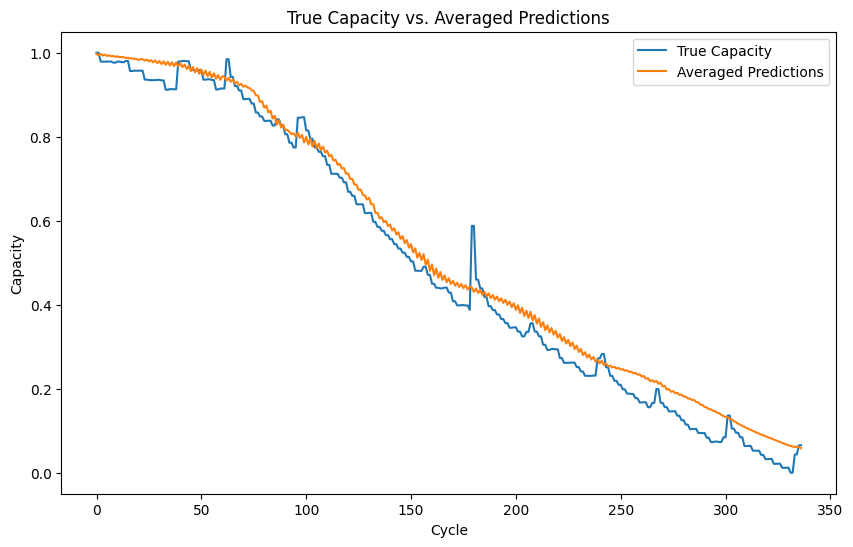

In [ ]:
# Group predictions by cycle and calculate the average
grouped_predictions = pd.DataFrame({'Cycle': X['cycle'], 'Predicted_Capacity': predicted_capacity.flatten()})
averaged_predictions = grouped_predictions.groupby('Cycle')['Predicted_Capacity'].mean().reset_index()

# Group true capacity by cycle and take the first capacity value for each cycle
grouped_true_capacity = pd.DataFrame({'Cycle': X['cycle'], 'True_Capacity': y})
grouped_true_capacity = grouped_true_capacity.groupby('Cycle')['True_Capacity'].first().reset_index()

# Check the length of true capacity and averaged prediction
if len(grouped_true_capacity) != len(averaged_predictions):
    print("The length of the true capacity and averaged predictions is different.")
    print(f"True Capacity Length: {len(grouped_true_capacity)}, Averaged Predictions Length: {len(averaged_predictions)}")

# Plot the true capacity and averaged predictions
plt.figure(figsize=(10, 6))
plt.plot(grouped_true_capacity['True_Capacity'], label='True Capacity')
plt.plot(averaged_predictions['Predicted_Capacity'], label='Averaged Predictions')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.legend()
plt.title('True Capacity vs. Averaged Predictions')
plt.show()


the below is the preferred format this should be altered to show only the DISCHARGE ALONE

True Capacity Length: 337, Averaged Predictions Length: 337


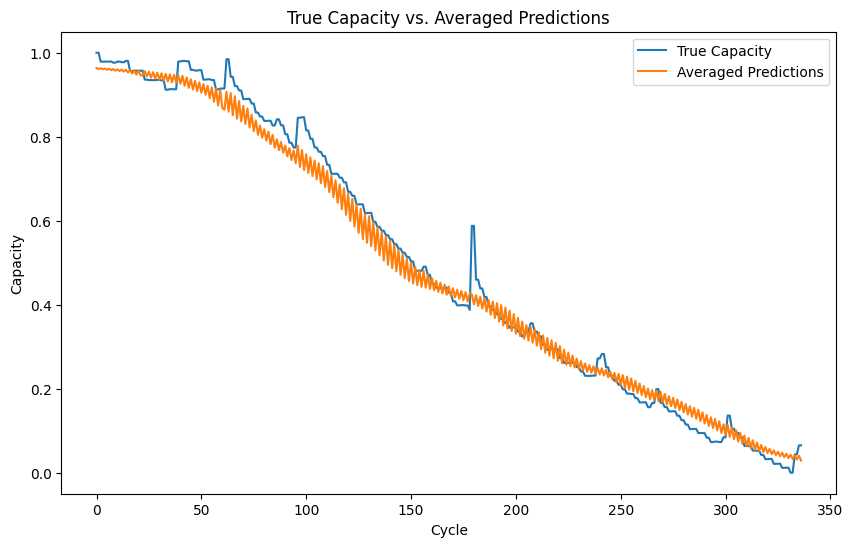

In [ ]:
# Group predictions by cycle and calculate the average
grouped_predictions = pd.DataFrame({'Cycle': X['cycle'], 'Predicted_Capacity': predicted_capacity.flatten()})
averaged_predictions = grouped_predictions.groupby('Cycle')['Predicted_Capacity'].mean().reset_index()

# Group true capacity by cycle and take the first capacity value for each cycle
grouped_true_capacity = pd.DataFrame({'Cycle': X['cycle'], 'True_Capacity': y})
grouped_true_capacity = grouped_true_capacity.groupby('Cycle')['True_Capacity'].first().reset_index()

print(f"True Capacity Length: {len(grouped_true_capacity)}, Averaged Predictions Length: {len(averaged_predictions)}")

# Check the length of true capacity and averaged prediction
if len(grouped_true_capacity) != len(averaged_predictions):
    print("The length of the true capacity and averaged predictions is different.")
    print(f"True Capacity Length: {len(grouped_true_capacity)}, Averaged Predictions Length: {len(averaged_predictions)}")

# Plot the true capacity and averaged predictions
plt.figure(figsize=(10, 6))
plt.plot(grouped_true_capacity['True_Capacity'], label='True Capacity')
plt.plot(averaged_predictions['Predicted_Capacity'], label='Averaged Predictions')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.legend()
plt.title('True Capacity vs. Averaged Predictions')
plt.show()


### error metric calculation from the averaged prediction model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE, MSE, and MAE
rmse = np.sqrt(mean_squared_error(grouped_true_capacity['True_Capacity'], averaged_predictions['Predicted_Capacity']))
mse = mean_squared_error(grouped_true_capacity['True_Capacity'], averaged_predictions['Predicted_Capacity'])
mae = mean_absolute_error(grouped_true_capacity['True_Capacity'], averaged_predictions['Predicted_Capacity'])

print(f"RMSE: {rmse}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")


RMSE: 0.03934168749700042
MSE: 0.0015477683751116394
MAE: 0.029980695595776933


### error metric calculation from the model directly

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, predicted_capacity)
print("Mean Squared Error:", mse)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y, predicted_capacity)
print("Mean Absolute Error:", mae)


Mean Squared Error: 0.0010906895998845103
Root Mean Squared Error: 0.03302559007625012
Mean Absolute Error: 0.02618143151933447


## testing dataset using B0006 for **BiLSTM model code suitable for CHARGE + DISCHARGE (present)**

Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 2.035337591005598, 4.179799607333447, -0.0023663271409738672, 24.277567510331888, 0.0]
1577/1577 [==============================] - 24s 15ms/step


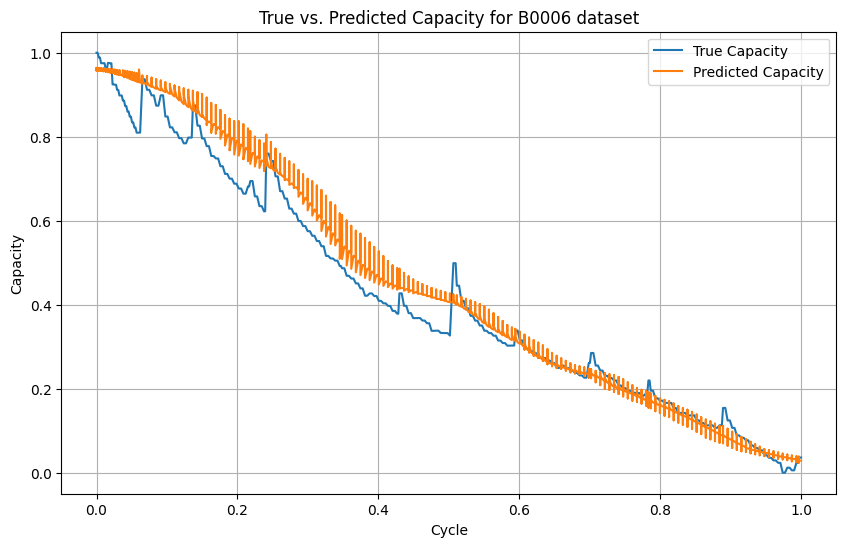

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0006')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

# Define input shape and number of classes
input_shape = (sequence_length, num_features)
num_classes = 1

# Load the trained model weights
model = HFCM_BiLSTM(input_shape, num_classes)


model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Plot the true and predicted capacity
plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(X['cycle'], predicted_capacity, label='Predicted Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0006 dataset')
plt.legend()
plt.grid()
plt.show()


### averaged prediction and true capacity also scaled down based on without repetition of capacity

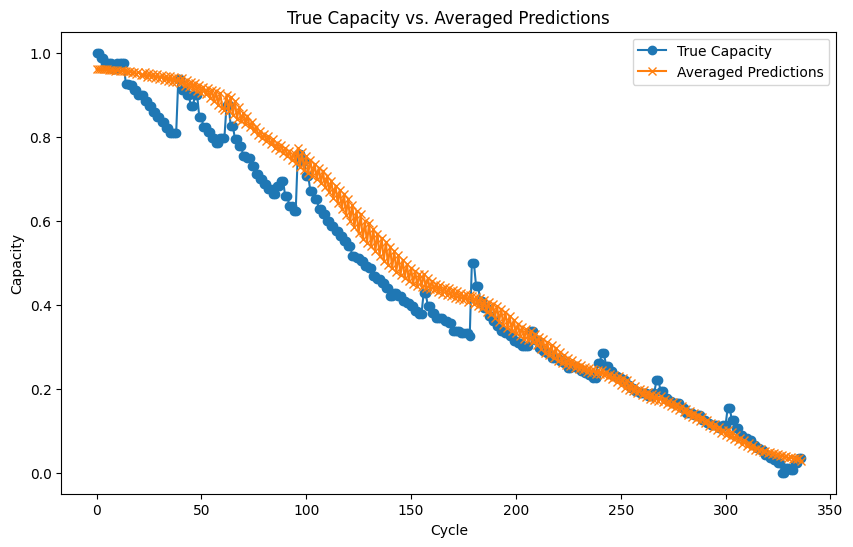

In [ ]:
# Group predictions by cycle and calculate the average
grouped_predictions = pd.DataFrame({'Cycle': X['cycle'], 'Predicted_Capacity': predicted_capacity.flatten()})
averaged_predictions = grouped_predictions.groupby('Cycle')['Predicted_Capacity'].mean().reset_index()

# Group true capacity by cycle and take the first capacity value for each cycle
grouped_true_capacity = pd.DataFrame({'Cycle': X['cycle'], 'True_Capacity': y})
grouped_true_capacity = grouped_true_capacity.groupby('Cycle')['True_Capacity'].first().reset_index()

# Check the length of true capacity and averaged prediction
if len(grouped_true_capacity) != len(averaged_predictions):
    print("The length of the true capacity and averaged predictions is different.")
    print(f"True Capacity Length: {len(grouped_true_capacity)}, Averaged Predictions Length: {len(averaged_predictions)}")

# Plot the true capacity and averaged predictions
plt.figure(figsize=(10, 6))
plt.plot(grouped_true_capacity['True_Capacity'], label='True Capacity', marker='o')
plt.plot(averaged_predictions['Predicted_Capacity'], label='Averaged Predictions', marker='x')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.legend()
plt.title('True Capacity vs. Averaged Predictions')
plt.show()


the below is the preferred format this should be altered to show only the DISCHARGE ALONE

True Capacity Length: 337, Averaged Predictions Length: 337


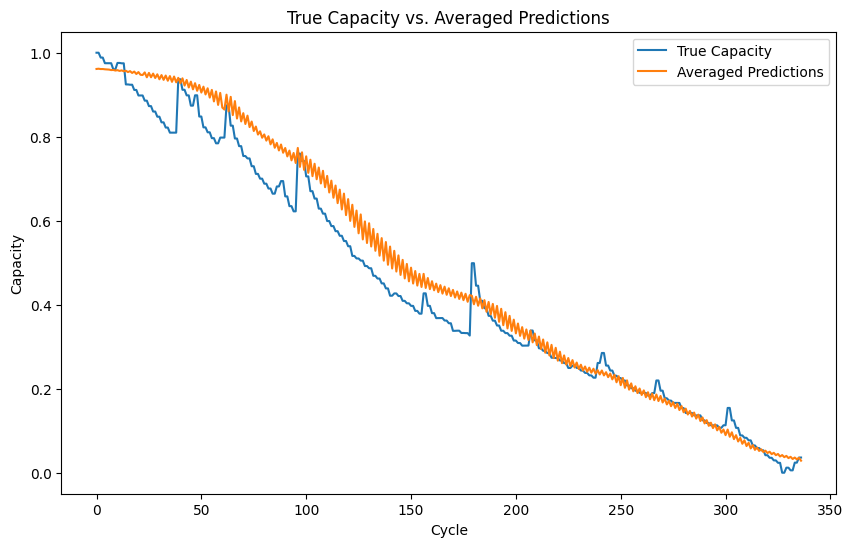

In [ ]:
# Group predictions by cycle and calculate the average
grouped_predictions = pd.DataFrame({'Cycle': X['cycle'], 'Predicted_Capacity': predicted_capacity.flatten()})
averaged_predictions = grouped_predictions.groupby('Cycle')['Predicted_Capacity'].mean().reset_index()

# Group true capacity by cycle and take the first capacity value for each cycle
grouped_true_capacity = pd.DataFrame({'Cycle': X['cycle'], 'True_Capacity': y})
grouped_true_capacity = grouped_true_capacity.groupby('Cycle')['True_Capacity'].first().reset_index()

print(f"True Capacity Length: {len(grouped_true_capacity)}, Averaged Predictions Length: {len(averaged_predictions)}")

# Check the length of true capacity and averaged prediction
if len(grouped_true_capacity) != len(averaged_predictions):
    print("The length of the true capacity and averaged predictions is different.")
    print(f"True Capacity Length: {len(grouped_true_capacity)}, Averaged Predictions Length: {len(averaged_predictions)}")

# Plot the true capacity and averaged predictions
plt.figure(figsize=(10, 6))
plt.plot(grouped_true_capacity['True_Capacity'], label='True Capacity')
plt.plot(averaged_predictions['Predicted_Capacity'], label='Averaged Predictions')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.legend()
plt.title('True Capacity vs. Averaged Predictions')
plt.show()


### error metric calculation from the averaged prediction model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE, MSE, and MAE
rmse = np.sqrt(mean_squared_error(grouped_true_capacity['True_Capacity'], averaged_predictions['Predicted_Capacity']))
mse = mean_squared_error(grouped_true_capacity['True_Capacity'], averaged_predictions['Predicted_Capacity'])
mae = mean_absolute_error(grouped_true_capacity['True_Capacity'], averaged_predictions['Predicted_Capacity'])

print(f"RMSE: {rmse}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")


RMSE: 0.06026406838975849
MSE: 0.0036317579388854887
MAE: 0.046230550001541526


### error metric calculation from the model directly

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, predicted_capacity)
print("Mean Squared Error:", mse)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y, predicted_capacity)
print("Mean Absolute Error:", mae)


Mean Squared Error: 0.004913861281510473
Root Mean Squared Error: 0.07009893923241972
Mean Absolute Error: 0.05456266642808453


# untested reference results

## for B0005 dataset itself we are predicting for test set

In [ ]:
# Predict using the trained model
predicted_capacity = model.predict(reshaped_features_test_combined)

In [ ]:
# Plot the predicted capacity vs. cycle
plt.figure(figsize=(10, 6))

# Get the 'cycle' values from the original X_test_combined DataFrame
cycles = X_test_combined['cycle']

plt.plot(cycles, y_test_combined, color='red', label='True Capacity')
plt.plot(cycles, predicted_capacity, color='green', label='Predicted Capacity', linestyle='dashed')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for Combined Dataset')
plt.legend()
plt.grid()
plt.show()


## testing dataset using B0006 (we used the same dataset for training)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0006')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

# Define input shape and number of classes
input_shape = (sequence_length, num_features)
num_classes = 1

# Load the trained model weights
model = HFCM_LSTM(input_shape, num_classes)

model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Plot the true and predicted capacity
plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(X['cycle'], predicted_capacity, label='Predicted Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0006 dataset')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Plot the predicted capacity vs. cycle
plt.figure(figsize=(10, 6))
plt.scatter(X['cycle'], predicted_capacity, color='blue', label='Predicted Capacity')
plt.scatter(X['cycle'], y, color='red', label='True Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('Predicted vs. True Capacity')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, predicted_capacity)
print("Mean Squared Error:", mse)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y, predicted_capacity)
print("Mean Absolute Error:", mae)


## testing dataset using B0018

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, Multiply
import matplotlib.pyplot as plt
from scipy.io import loadmat  # Make sure you have this import if it's used in the load_data function

# Load the dataset (assuming the dataset and preprocessing steps are available)
dataset, capacity = load_data('B0018')  # Make sure you have the 'load_data' function defined
# To normalize the data
dataset = normalize_data(dataset)  # Make sure you have the 'normalize_data' function defined
X = dataset[['cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'time']]
y = dataset['capacity']

# Reshape features to match the desired format (sequence_length, num_features)
sequence_length = 400
num_features = 4  # cycle, Voltage, current, and temperature

# Reshape data
num_samples = len(X)
reshaped_features = np.zeros((num_samples, sequence_length, num_features))
for i, (_, row) in enumerate(X.iterrows()):
    cycle = row['cycle']
    voltage = row['voltage_measured']
    current = row['current_measured']
    temperature = row['temperature_measured']
    reshaped_features[i, :, :] = np.array([cycle, voltage, current, temperature])

# Define input shape and number of classes
input_shape = (sequence_length, num_features)
num_classes = 1

# Load the trained model weights
model = HFCM_LSTM(input_shape, num_classes)

model.load_weights(path_to_saved_weights)  # Replace with the actual path to the saved weights

# Predict capacity using the trained model
predicted_capacity = model.predict(reshaped_features)

# Plot the true and predicted capacity
plt.figure(figsize=(10, 6))
plt.plot(X['cycle'], y, label='True Capacity')
plt.plot(X['cycle'], predicted_capacity, label='Predicted Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('True vs. Predicted Capacity for B0006 dataset')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Plot the predicted capacity vs. cycle
plt.figure(figsize=(10, 6))
plt.scatter(X['cycle'], predicted_capacity, color='blue', label='Predicted Capacity')
plt.scatter(X['cycle'], y, color='red', label='True Capacity')
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('Predicted vs. True Capacity')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, predicted_capacity)
print("Mean Squared Error:", mse)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y, predicted_capacity)
print("Mean Absolute Error:", mae)
